In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib 
%matplotlib inline

# 1.数据处理

In [7]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
train.head(),test.head()

(   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
 0   1          60       RL         65.0     8450   Pave   NaN      Reg   
 1   2          20       RL         80.0     9600   Pave   NaN      Reg   
 2   3          60       RL         68.0    11250   Pave   NaN      IR1   
 3   4          70       RL         60.0     9550   Pave   NaN      IR1   
 4   5          60       RL         84.0    14260   Pave   NaN      IR1   
 
   LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
 0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
 1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
 2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
 3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
 4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   
 
   YrSold  SaleType  SaleCondition  SalePrice  
 0   2

In [6]:
train.shape,test.shape

((1460, 81), (1459, 80))

In [23]:
all_features=pd.concat([train.iloc[:,1:-1],test.iloc[:,1:]])

```python
value_features=all_features[all_features.columns[all_features.dtypes != 'object']] 
#直接索引后赋值是视图,但是这里先赋值给了value_featrues,所以成为了copy

value_features=value_features.apply(lambda x: (x-x.mean())/x.std(),axis=0).fillna(0.)

value_features.head(),all_features.head()

(   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \...
 0    0.067320    -0.184443 -0.217841     0.646073    -0.507197   1.046078   
 1   -0.873466     0.458096 -0.072032    -0.063174     2.187904   0.154737   
 2    0.067320    -0.055935  0.137173     0.646073    -0.507197   0.980053   
 3    0.302516    -0.398622 -0.078371     0.646073    -0.507197  -1.859033   
 4    0.067320     0.629439  0.518814     1.355319    -0.507197   0.947040   
 
     MiscVal    MoSold    YrSold  
 0 -0.089577 -1.551918  0.157619  
 1 -0.089577 -0.446848 -0.602858  
 2 -0.089577  1.026577  0.157619  
 3 -0.089577 -1.551918 -1.363335  
 4 -0.089577  2.131647  0.157619  
 
 [5 rows x 36 columns],
    MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \...
 0          60       RL         65.0     8450   Pave   NaN      Reg   
 1          20       RL         80.0     9600   Pave   NaN      Reg   
 2          60       RL         68.0    11250   Pave   NaN      IR1   
 3          70       RL         60.0     9550   Pave   NaN      IR1   
 4          60       RL         84.0    14260   Pave   NaN      IR1   
 
   MiscFeature MiscVal  MoSold  YrSold  SaleType  SaleCondition  
 0         NaN       0       2    2008        WD         Normal  
 1         NaN       0       5    2007        WD         Normal  
 2         NaN       0       9    2008        WD         Normal  
 3         NaN       0       2    2006        WD        Abnorml  
 4         NaN       0      12    2008        WD         Normal  
 
 [5 rows x 79 columns])
 ```
 所以修改一下,一直使用索引

In [62]:
value_features_column=all_features.columns[all_features.dtypes != 'object']

In [63]:
all_features[value_features_column]=all_features[value_features_column]\
    .apply(lambda x: (x-x.mean())/x.std(),axis=0)\
    .fillna(0.)

In [92]:
dummies_features=pd.get_dummies(all_features,dummy_na=True,dtype=float) 
#默认是bool,而混合float和bool会导致格式为 'object'

In [89]:
dummies_features.shape

(2919, 330)

In [120]:
n_train=train.shape[0]
train_features=torch.tensor(dummies_features[:n_train].values,dtype=torch.float32)
train_labels=torch.tensor(train.iloc[:,-1].values.reshape(-1,1),dtype=torch.float32) #注意:这里标签是二维的
test_features=torch.tensor(dummies_features[n_train:].values,dtype=torch.float32)

# 2.训练

先训练一个线性模型作为baseline,如果模型不能比随机猜测好,说明数据处理有问题.  
如果一切正常,这将作为基准,判断别的模型会好多少.

In [102]:
loss=nn.MSELoss()
in_features=train_features.shape[1]

def get_net():
    net=nn.Sequential(nn.Linear(in_features,1))
    return net

对于房价,我们更关心相对误差$\frac{y - \hat{y}}{y}$,而非绝对误差.  
**解决这个问题的一种方法是用价格预测的对数来衡量差异**  
即将$\delta$ for $|\log y - \log \hat{y}| \leq \delta$
转换为$e^{-\delta} \leq \frac{\hat{y}}{y} \leq e^\delta$。
这使得预测价格的对数与真实标签价格的对数之间出现以下均方根误差(RMSE)：

$$\sqrt{\frac{1}{n}\sum_{i=1}^n\left(\log y_i -\log \hat{y}_i\right)^2}.$$


因为$e^x - 1 \sim x \quad (x \to 0)$,所以这里均方根误差 $\delta$ 在对数空间可解释为百分比误差的度量.  
eg: $δ=0.1$ 对应约 $±10\% $ 的相对误差($e^{0.1}=1.105,e^{-0.1}=0.905$)

In [106]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

**torch.clamp** : $y_i = \min(\max(x_i, \text{min\_value}_i), \text{max\_value}_i)$

我们这里训练函数借助Adam优化器,它对初始学习率不那么敏感.

In [134]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator.
    data_arrays: pytorch data, must have dimension 
    batch_size: the size of feature in each iter 
    is_train: shuffle or not
    """
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [136]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls,test_ls=[],[]
    train_iter=load_array((train_features,train_labels), batch_size,is_train=True)

    optimizer=torch.optim.Adam(net.parameters(),
                               lr=learning_rate,
                               weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X,y in train_iter:
            optimizer.zero_grad()
            l=loss(net(X),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net,train_features,train_labels))  #log_rmse不是用于训练的
        if test_labels is not None:
            test_ls.append(log_rmse(net,test_features,test_labels))
    return train_ls,test_ls

# 3.K折交叉验证

In [137]:
def get_k_fold_data(k, i, X, y):
    '''
    划分数据,重复执行该函数k次即可得到k折
    '''
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

In [140]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练 log rmse: {float(train_ls[-1]):f}, '
              f'验证 log rmse: {float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

# 4.模型选择

通过K折交叉验证来选择合适的超参数.
<mark>注意:我们这里只是做了一个线性的baseline</mark>


请注意，有时一组超参数的训练误差可能非常低，但$K$折交叉验证的误差要高得多，
这表明模型过拟合了。  
在整个训练过程中，我们希望监控训练误差和验证误差这两个数字。
较少的过拟合可能表明现有数据可以支撑一个更强大的模型(增加模型复杂度)，
较大的过拟合可能意味着我们可以通过正则化技术来获益(引入正则化)。

折1，训练log rmse0.170113, 验证log rmse0.156474
折2，训练log rmse0.162144, 验证log rmse0.190008
折3，训练log rmse0.163952, 验证log rmse0.168877
折4，训练log rmse0.168101, 验证log rmse0.154802
折5，训练log rmse0.163395, 验证log rmse0.182952
5-折验证: 平均训练log rmse: 0.165541, 平均验证log rmse: 0.170623


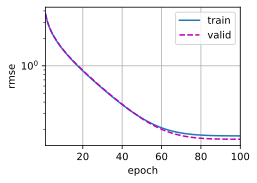

In [139]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

# 5.提交

选出来之后在整个训练集上训练,然后对测试集进行预测,得到的结果就可以提交了.